In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def plot_slices(slices, titles=None, cmap="gray", origin="lower"):
    """Function to display a row of image slices."""
    n_slices = len(slices)
    fig, axes = plt.subplots(1, n_slices, figsize=(3.5 * n_slices, 3.8))

    if len(slices) > 1:
        for i, slice_array in enumerate(slices):
            axes[i].imshow(slice_array, cmap=cmap, origin=origin, aspect="auto")
            if titles is not None:
                axes[i].set_title(titles[i])
            axes[i].grid(False)
    else:
        axes.imshow(slices[0], cmap=cmap, origin=origin)
        if titles is not None:
            axes.set_title(titles[0])
        axes.grid(False)

In [ ]:
# https://chatgpt.com/s/t_6924d5f491688191b8c4d83a8c2f2bc8
import numpy as np
from scipy.optimize import minimize
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.utils.validation import check_array


class MP_PCA(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        sigma_estimator="median",
        n_components=None,
        regression=False,
        verbose=True,
    ):
        """
        Marchenko-Pastur PCA (high-dimensional).

        Parameters
        ----------
        sigma_estimator : str
            Method to estimate noise variance:
            "median", "bulk_mean", "min_eigen", "mp_fit"
        n_components : int or None
            Maximum number of components to keep
        regression : bool
            Whether to fit LinearRegression on Y in fit()
        verbose : bool
            Print info
        """
        self.sigma_estimator = sigma_estimator
        self.n_components = n_components
        self.regression = regression
        self.verbose = verbose

    def fit(self, X, Y=None):
        X = check_array(X, ensure_2d=True, dtype=float)
        n, p = X.shape
        self.n_samples_ = n
        self.n_features_ = p
        self.gamma_ = p / n

        # Center the data
        self.mean_ = np.mean(X, axis=0)
        Xc = X - self.mean_

        # Economy SVD
        U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
        eigenvals = (S**2) / n

        self.U_ = U
        self.S_ = S
        self.Vt_ = Vt
        self.eigenvalues_ = eigenvals

        # Estimate sigma^2
        if self.sigma_estimator == "median":
            sigma2_hat = np.median(eigenvals) / (1 + self.gamma_)
        elif self.sigma_estimator == "bulk_mean":
            sigma2_hat = np.mean(eigenvals)
        elif self.sigma_estimator == "min_eigen":
            sigma2_hat = np.min(eigenvals) / (1 - np.sqrt(self.gamma_)) ** 2
        elif self.sigma_estimator == "mp_fit":
            # simple MP fit using KL divergence or least-squares of bulk histogram
            sigma2_hat = self._fit_mp_bulk(eigenvals, self.gamma_)
        else:
            raise ValueError(f"Unknown sigma_estimator {self.sigma_estimator}")

        sigma2_hat = 35  # TODO REMOVE
        self.sigma2_ = sigma2_hat
        self.lambda_mp_max_ = sigma2_hat * (1 + np.sqrt(self.gamma_)) ** 2

        # Retain spikes
        kept_mask = eigenvals > self.lambda_mp_max_
        kept_idx = np.where(kept_mask)[0]

        if self.n_components is not None:
            kept_idx = kept_idx[: self.n_components]

        self.kept_idx_ = kept_idx
        V = Vt.T
        self.pcs_ = V[:, kept_idx] if len(kept_idx) > 0 else np.zeros((p, 0))
        self.scores_ = Xc @ self.pcs_ if len(kept_idx) > 0 else np.zeros((n, 0))

        # Optional regression on Y
        self.reg_ = None
        self.r2_ = None
        if Y is not None and self.regression:
            Y = np.asarray(Y).reshape(-1)
            if self.scores_.shape[1] > 0:
                self.reg_ = LinearRegression()
                self.reg_.fit(self.scores_, Y)
                Y_pred = self.reg_.predict(self.scores_)
                self.r2_ = r2_score(Y, Y_pred)
            elif self.verbose:
                print("No MP components retained, regression skipped")

        if self.verbose:
            print(f"Estimated sigma^2: {self.sigma2_:.6g}")
            print(f"MP upper edge: {self.lambda_mp_max_:.6g}")
            print(f"Number of components retained: {self.pcs_.shape[1]}")

        return self

    def transform(self, X):
        """Return the denoised reconstruction with the same shape as X."""
        X = check_array(X, ensure_2d=True, dtype=float)
        Xc = X - self.mean_
        scores = Xc @ self.pcs_          # (n, k)
        return scores @ self.pcs_.T + self.mean_  # (n, m) — reconstructed

    def fit_transform(self, X, Y=None):
        """Fit and return the denoised reconstruction with the same shape as X."""
        self.fit(X, Y)
        return self.scores_ @ self.pcs_.T + self.mean_  # (n, m) — reconstructed

    # -------------------------------
    # Private helper: simple MP fit
    # -------------------------------
    def _fit_mp_bulk(self, eigenvals, gamma):
        """
        Fit sigma^2 to match the bulk of eigenvalues to MP upper edge using least squares.
        This is a simple implementation.
        """

        def loss(sigma2):
            sigma2 = float(sigma2)
            lambda_max = sigma2 * (1 + np.sqrt(gamma)) ** 2
            bulk = eigenvals[eigenvals <= lambda_max]
            # we try to fit median of bulk = sigma2*(1+gamma)
            target = sigma2 * (1 + gamma)
            return (np.median(bulk) - target) ** 2

        res = minimize(
            loss, x0=[np.median(eigenvals) / (1 + gamma)], bounds=[(1e-12, None)]
        )
        return float(res.x)

    def get_params(self, deep=True):
        return {
            "sigma_estimator": self.sigma_estimator,
            "n_components": self.n_components,
            "regression": self.regression,
            "verbose": self.verbose,
        }

    def set_params(self, **params):
        for k, v in params.items():
            setattr(self, k, v)
        return self


# # -----------------------
# # Example usage
# # -----------------------
# if __name__ == "__main__":
#     # Simulated high-dimensional data
#     np.random.seed(0)
#     X = np.random.randn(600, 1388)
#     # add a low-rank signal
#     X += np.outer(np.random.randn(600), np.array([2.5, 1.8, 1.2]).repeat(462)[:1388]) * 0.4
#     Y = np.random.randn(600)

#     # Initialize MP-PCA
#     mp_pca = MP_PCA(sigma_estimator="median", regression=True, verbose=True)
#     mp_pca.fit(X, Y)

#     # Project new data
#     X_proj = mp_pca.transform(X)

#     print("Retained components:", mp_pca.pcs_.shape[1])
#     if mp_pca.reg_ is not None:
#         print("R^2 on training:", mp_pca.r2_)


In [5]:
tumor_slice = np.load("sim_data/sample_tumor_img.npy")
tumor_slice.shape

(184, 132)

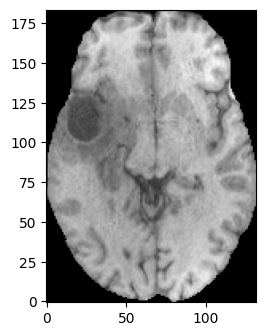

In [6]:
plot_slices([tumor_slice])

In [7]:
pad_tumor_slice = np.pad(tumor_slice, pad_width=5, mode="constant", constant_values=0)
pad_tumor_slice.shape

(194, 142)

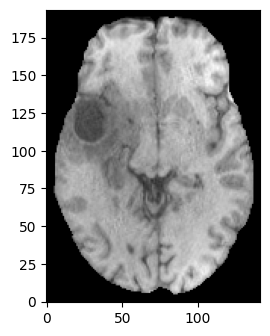

In [8]:
# Title: "Original brain slice"
plot_slices([pad_tumor_slice])

In [12]:
from denoise_rmt import (
    ImgNoiseCorruptor,
    apply_foreground_masks,
    normalize_imgs_0_255,
)

noise_corruptor = ImgNoiseCorruptor(original_img=pad_tumor_slice)

In [13]:
# RNG seed
seed = 1

# Noise parameters
sigma = 35  # Marchenko-Pastur sigma ~ noise standard deviation
rice_b = 2  # Rice distribution parameter

# Generate noisy snapshot and foreground mask
snapshots, fg_masks = noise_corruptor.generate_rician_noisy_displaced_imgs(
    n_snapshots=1,
    rice_b=rice_b,
    sigma=sigma,
    seed=seed,
)
snapshot = snapshots[0]
fg_mask = fg_masks[0]

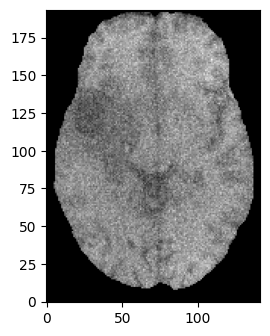

In [14]:
# Title: "Sample of corrupted image"
plot_slices([snapshot])

Estimated sigma^2: 35
MP upper edge: 120.507
Number of components retained: 118
Denoised snapshot shape: (194, 142)


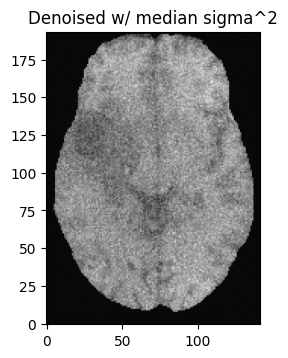

In [41]:
mp_pca = MP_PCA(sigma_estimator="median", regression=False, verbose=True)

denoised_snapshot_median = mp_pca.fit_transform(snapshot)
print(f"Denoised snapshot shape: {denoised_snapshot_median.shape}")
plot_slices([denoised_snapshot_median], titles=["Denoised w/ median sigma^2"])

Estimated sigma^2: 35
MP upper edge: 120.507
Number of components retained: 118
Denoised snapshot shape: (194, 142)


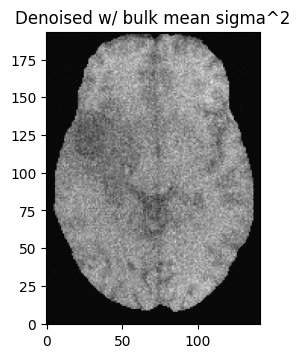

In [42]:
mp_pca = MP_PCA(sigma_estimator="bulk_mean", regression=False, verbose=True)

denoised_snapshot_bulk_mean = mp_pca.fit_transform(snapshot)
print(f"Denoised snapshot shape: {denoised_snapshot_bulk_mean.shape}")
plot_slices([denoised_snapshot_bulk_mean], titles=["Denoised w/ bulk mean sigma^2"])

Estimated sigma^2: 1.76182e-25
MP upper edge: 6.06603e-25
Number of components retained: 132
Denoised snapshot shape: (194, 142)


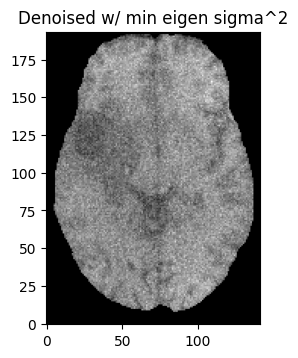

In [34]:
mp_pca = MP_PCA(sigma_estimator="min_eigen", regression=False, verbose=True)

denoised_snapshot_min_eigen = mp_pca.fit_transform(snapshot)
print(f"Denoised snapshot shape: {denoised_snapshot_min_eigen.shape}")
plot_slices([denoised_snapshot_min_eigen], titles=["Denoised w/ min eigen sigma^2"])

Estimated sigma^2: 1e-12
MP upper edge: 3.44305e-12
Number of components retained: 132
Denoised snapshot shape: (194, 142)


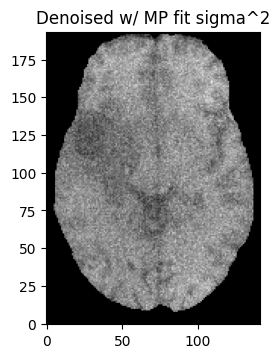

In [35]:
mp_pca = MP_PCA(sigma_estimator="mp_fit", regression=False, verbose=True)

denoised_snapshot_mp_fit = mp_pca.fit_transform(snapshot)
print(f"Denoised snapshot shape: {denoised_snapshot_mp_fit.shape}")
plot_slices([denoised_snapshot_mp_fit], titles=["Denoised w/ MP fit sigma^2"])

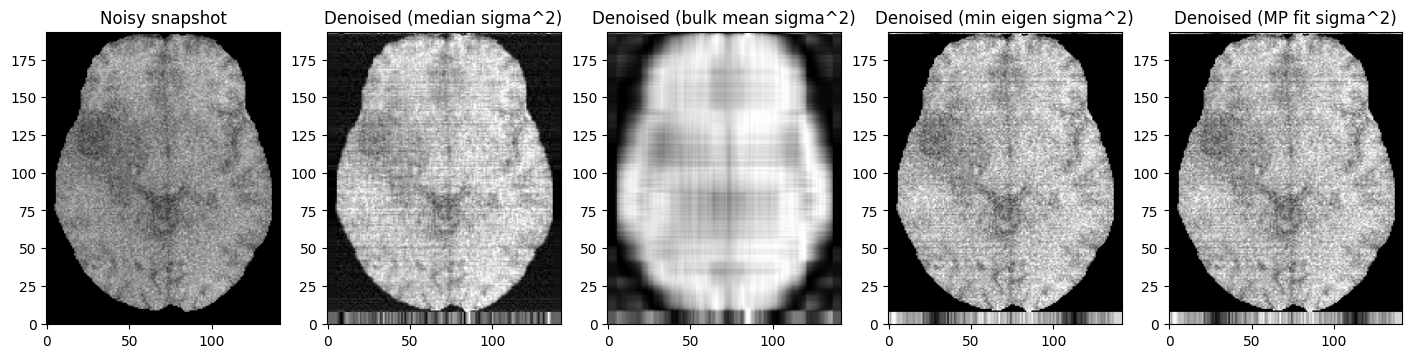

In [37]:
plot_slices(
    [
        snapshot,
        normalize_imgs_0_255(denoised_snapshot_median),
        normalize_imgs_0_255(denoised_snapshot_bulk_mean),
        normalize_imgs_0_255(denoised_snapshot_min_eigen),
        normalize_imgs_0_255(denoised_snapshot_mp_fit),
    ],
    titles=[
        "Noisy snapshot",
        "Denoised (median sigma^2)",
        "Denoised (bulk mean sigma^2)",
        "Denoised (min eigen sigma^2)",
        "Denoised (MP fit sigma^2)",
    ],
)

In [9]:
import numpy as np
from scipy.optimize import minimize
from typing import Optional

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted

try:
    # Package scikit-rmt installed
    from skrmt.ensemble import WishartEnsemble
except ModuleNotFoundError:
    # Running directly from the simulations/ directory
    import sys
    sys.path.append("..")
    from skrmt.ensemble import WishartEnsemble


# ---------------------------------------------------------------------------
# Module-level private helpers – noise variance estimation
#
# These are kept as plain functions rather than methods because they are
# stateless utilities with no dependency on the class, and _fit_mp_bulk is
# called inside a SciPy optimisation loop where constructing a class instance
# on every iteration would be prohibitively expensive.
# ---------------------------------------------------------------------------

def _fit_mp_bulk(eigenvals: np.ndarray, gamma: float) -> float:
    """Estimate sigma² by numerically fitting the Marchenko-Pastur bulk median.

    The minimisation finds the value of sigma² such that the observed median
    of the eigenvalues that fall inside the MP bulk (i.e. below lambda_+)
    matches the expected midpoint of the MP support, sigma²·(1 + gamma).

    Args:
        eigenvals: 1-D array of sample-covariance eigenvalues (S²).
        gamma: aspect ratio p/n.

    Returns:
        Estimated noise variance sigma² (always positive).
    """
    def loss(x):
        sigma2 = float(x[0])
        lambda_max = sigma2 * (1.0 + np.sqrt(gamma)) ** 2
        bulk = eigenvals[eigenvals <= lambda_max]
        if len(bulk) == 0:
            # All eigenvalues above the predicted bulk edge – push sigma² up.
            return 1e10
        # Expected midpoint of the MP support: (lambda_+ + lambda_-) / 2 = sigma²·(1 + gamma)
        expected_median = sigma2 * (1.0 + gamma)
        return (np.median(bulk) - expected_median) ** 2

    x0 = max(float(np.median(eigenvals)) / (1.0 + gamma), 1e-12)
    result = minimize(loss, x0=[x0], bounds=[(1e-12, None)])
    return float(result.x[0])


def _estimate_sigma(eigenvals: np.ndarray, gamma: float, method: str) -> float:
    """Estimate the noise standard deviation sigma from the empirical eigenvalue
    spectrum of the sample covariance matrix, guided by the Marchenko-Pastur law.

    Under the MP law, a pure-noise (p x n) matrix with i.i.d. N(0, sigma²)
    entries produces sample-covariance eigenvalues whose distribution is
    entirely supported on [lambda_-, lambda_+] = [sigma²·(1-√gamma)², sigma²·(1+√gamma)²].
    Each estimator below exploits a different property of this support.

    Args:
        eigenvals: 1-D array of sample-covariance eigenvalues, i.e. the squared
            singular values of the normalised matrix (1/√n)·X.
        gamma: aspect ratio p/n.
        method: estimation strategy. One of:

            ``"median"``
                The midpoint of the MP support is sigma²·(1 + gamma).
                Using the empirical median as a proxy for that midpoint gives
                sigma² ≈ median(eigenvals) / (1 + gamma).
                Fast, robust, and works well in the typical regime gamma < 1.

            ``"bulk_mean"``
                The mean eigenvalue of the MP distribution equals sigma²
                (the population variance), so sigma² ≈ mean(eigenvals).
                Simple but sensitive to outlier spikes above the bulk.

            ``"min_eigen"``
                The lower MP edge is lambda_- = sigma²·(1 - √gamma)², so
                sigma² ≈ min(eigenvals) / (1 - √gamma)².
                Accurate when the smallest eigenvalue sits close to lambda_-,
                but numerically unstable when gamma ≈ 1 (lower edge → 0);
                falls back to ``"bulk_mean"`` in that case.

            ``"mp_fit"``
                Numerically minimises the discrepancy between the observed bulk
                median and its theoretical MP prediction (uses SciPy).
                Most accurate but slowest; suitable when patches are large.

    Returns:
        Estimated noise standard deviation sigma (strictly positive).

    Raises:
        ValueError: if *method* is not one of the four supported options.
    """
    if method == "median":
        # Bulk median ≈ sigma²·(1 + gamma)  →  sigma² ≈ median / (1 + gamma)
        sigma2 = float(np.median(eigenvals)) / (1.0 + gamma)

    elif method == "bulk_mean":
        # E[lambda] = sigma²  under the MP law
        sigma2 = float(np.mean(eigenvals))

    elif method == "min_eigen":
        # Lower MP edge: lambda_- = sigma²·(1 - √gamma)²
        denom = (1.0 - np.sqrt(gamma)) ** 2
        if denom < 1e-10:
            # gamma ≈ 1: lower edge collapses to 0, estimator is ill-defined;
            # fall back to the mean estimator which remains well-behaved.
            sigma2 = float(np.mean(eigenvals))
        else:
            sigma2 = float(np.min(eigenvals)) / denom

    elif method == "mp_fit":
        sigma2 = _fit_mp_bulk(eigenvals, gamma)

    else:
        raise ValueError(
            f"Unknown sigma_estimator: '{method}'. "
            "Valid options are: 'median', 'bulk_mean', 'min_eigen', 'mp_fit'."
        )

    # Guard against non-positive values caused by degenerate inputs
    return float(np.sqrt(max(sigma2, 1e-12)))


# ---------------------------------------------------------------------------
# Public class
# ---------------------------------------------------------------------------

class MPPCADenoiser(BaseEstimator, TransformerMixin):
    """Patch-based image denoiser using Marchenko-Pastur PCA (MP-PCA).

    Denoises a stack of *p* noisy acquisitions of the same scene (e.g.
    repeated MRI scans of the same brain region) by exploiting the redundancy
    across acquisitions.  For every ``window_size × window_size`` spatial
    patch, the ``(p, window_size²)`` data matrix is denoised via economy SVD
    with hard thresholding of singular values against the Marchenko-Pastur
    (MP) upper spectral edge:
        lambda_+ = sigma²·(1 + √gamma)²,   gamma = p / (window_size²).

    Singular values whose square lies in the MP noise bulk (≤ lambda_+) are
    zeroed out; those above are treated as true signal and preserved.
    Overlapping patches are averaged at the end to eliminate block artefacts.

    This class follows the scikit-learn ``BaseEstimator`` / ``TransformerMixin``
    interface, making it composable in ``Pipeline`` objects and compatible with
    ``GridSearchCV`` for hyperparameter tuning.

    Parameters
    ----------
    sigma : float or None, default=None
        Noise standard deviation, assumed common to all images and spatial
        positions.  If ``None``, *sigma* is estimated from the eigenvalue bulk
        of the (flattened) image stack during ``fit`` using the method selected
        by ``sigma_estimator``.
    sigma_estimator : str, default="median"
        Method used to estimate *sigma* when it is not provided.  One of:

        * ``"median"``    – bulk median / (1 + gamma).  Fast and robust.
        * ``"bulk_mean"`` – mean eigenvalue; unbiased but spike-sensitive.
        * ``"min_eigen"`` – smallest eigenvalue / (1 − √gamma)²; accurate
                            for small gamma, unstable near gamma = 1.
        * ``"mp_fit"``    – least-squares fit of the MP bulk median (SciPy);
                            slowest but most accurate.

        Ignored when *sigma* is explicitly provided.
    window_size : int, default=16
        Side length in pixels of each square patch.  Larger windows improve
        eigenvalue statistics but reduce spatial adaptivity.

    Attributes
    ----------
    sigma_ : float
        Noise standard deviation used for denoising; either the value passed
        as ``sigma`` or the estimate learned during ``fit``.
    lambda_plus_ : float
        Marchenko-Pastur upper spectral edge computed from ``sigma_`` and the
        aspect ratio of the full (flattened) stack.  Informational only;
        per-patch thresholds are recomputed in ``transform`` using the actual
        patch dimensions via ``WishartEnsemble``.
    n_snapshots_ : int
        Number of images *p* seen during ``fit``.
    image_shape_ : tuple of int
        Spatial dimensions ``(height, width)`` of the images seen during ``fit``.

    Examples
    --------
    >>> denoiser = MPPCADenoiser(window_size=16)
    >>> denoised = denoiser.fit_transform(noisy_snapshots)   # (p, H, W)

    >>> # Known noise level – skip estimation:
    >>> denoiser = MPPCADenoiser(sigma=0.1, window_size=8)
    >>> denoiser.fit(train_stack)
    >>> denoised_test = denoiser.transform(test_stack)
    """

    def __init__(
        self,
        sigma: Optional[float] = None,
        sigma_estimator: str = "median",
        window_size: int = 16,
    ):
        self.sigma = sigma
        self.sigma_estimator = sigma_estimator
        self.window_size = window_size

    def fit(self, X: np.ndarray, y=None) -> "MPPCADenoiser":
        """Learn the noise level from the image stack *X*.

        If ``sigma`` was provided at construction time it is stored directly as
        ``sigma_``.  Otherwise *sigma* is estimated from the global eigenvalue
        distribution of the flattened stack using the method chosen by
        ``sigma_estimator``.

        Args:
            X: noisy image stack, shape ``(p, height, width)``.
            y: ignored; present only for scikit-learn API compatibility.

        Returns:
            self
        """
        X = self._check_input(X)
        p, h, w = X.shape

        # Store metadata about the training data for validation in transform
        self.n_snapshots_ = p
        self.image_shape_ = (h, w)

        if self.sigma is not None:
            # Caller supplied sigma: use it directly, no estimation needed.
            self.sigma_ = float(self.sigma)
        else:
            # Estimate sigma globally from the full (p, h*w) flattened matrix.
            # Normalise by 1/√(h*w) so squared singular values equal the
            # eigenvalues of the sample covariance — the quantity that the
            # Marchenko-Pastur law describes.
            n_pixels = h * w
            gamma = p / n_pixels
            X_flat = X.reshape(p, n_pixels)
            _, S, _ = np.linalg.svd(X_flat / np.sqrt(n_pixels), full_matrices=False)
            eigenvals = S ** 2
            self.sigma_ = _estimate_sigma(eigenvals, gamma, self.sigma_estimator)

        # Compute and expose the global MP upper edge via WishartEnsemble
        # (beta=1, real-valued entries).  This is informational; per-patch
        # thresholds are recomputed with the correct patch gamma in transform.
        wre = WishartEnsemble(beta=1, p=p, n=h * w, sigma=self.sigma_)
        self.lambda_plus_ = wre.lambda_plus

        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        """Denoise the image stack using patch-based MP-PCA.

        Applies sliding-window SVD hard-thresholding with the noise level
        ``sigma_`` learned during ``fit``.  Every ``window_size × window_size``
        patch is denoised independently; overlapping patches are averaged to
        suppress block artefacts and reduce residual variance.

        Args:
            X: noisy image stack, shape ``(p, height, width)``.  The spatial
                dimensions must match those seen during ``fit``.

        Returns:
            Denoised image stack with the same shape and dtype as *X*.

        Raises:
            sklearn.exceptions.NotFittedError: if called before ``fit``.
            ValueError: if the spatial dimensions of *X* differ from those
                seen during ``fit``, or if ``window_size`` exceeds the image
                dimensions.
        """
        check_is_fitted(self)
        X = self._check_input(X, expected_shape=self.image_shape_)
        return self._sliding_window_denoise(X)

    # fit_transform is inherited from TransformerMixin: it calls fit(X) then
    # transform(X), which is correct and efficient for this estimator.

    @staticmethod
    def _check_input(
        X: np.ndarray,
        expected_shape: Optional[tuple] = None,
    ) -> np.ndarray:
        """Validate and coerce the image stack array.

        Args:
            X: input array; must be 3-D (p, height, width).
            expected_shape: if provided, ``(height, width)`` that X must match.

        Returns:
            X cast to float64.

        Raises:
            ValueError: on wrong number of dimensions or mismatched shape.
        """
        X = np.asarray(X, dtype=float)
        if X.ndim != 3:
            raise ValueError(
                f"X must be a 3-D array (p, height, width), got shape {X.shape}."
            )
        if expected_shape is not None:
            _, h, w = X.shape
            if (h, w) != expected_shape:
                raise ValueError(
                    f"Spatial dimensions of X ({h}×{w}) do not match the "
                    f"dimensions seen during fit "
                    f"({expected_shape[0]}×{expected_shape[1]})."
                )
        return X

    def _denoise_patch(self, patch: np.ndarray) -> np.ndarray:
        """Denoise a single ``(p, n_pixels)`` patch matrix.

        Normalises the patch so that squared singular values equal sample-
        covariance eigenvalues, uses ``WishartEnsemble`` (beta=1) to obtain
        the validated MP upper spectral edge for the patch's own aspect ratio
        gamma = p / n_pixels, zeros out noise singular values, and reconstructs
        the denoised patch at the original (un-normalised) scale.

        Args:
            patch: ``(p, n_pixels)`` float array for one spatial window.

        Returns:
            Denoised ``(p, n_pixels)`` array.
        """
        p, n = patch.shape

        # Normalise: squared singular values become sample-covariance eigenvalues
        U, S, Vh = np.linalg.svd(patch / np.sqrt(n), full_matrices=False)

        # Use WishartEnsemble (beta=1, real entries) to compute the validated
        # MP upper edge for this patch's specific aspect ratio gamma = p/n.
        # lambda_+ = sigma_²·(1 + √gamma)²
        wre = WishartEnsemble(beta=1, p=p, n=n, sigma=self.sigma_)

        # Hard threshold: zero out singular values inside the noise bulk
        denoised_S = np.where(S <= np.sqrt(wre.lambda_plus), 0.0, S)

        # Rescale back to the original (non-normalised) domain and reconstruct
        return np.sqrt(n) * (U * denoised_S) @ Vh

    def _sliding_window_denoise(self, X: np.ndarray) -> np.ndarray:
        """Apply the sliding-window MP-PCA denoising loop.

        Iterates over all ``window_size × window_size`` overlapping patches,
        denoises each one via ``_denoise_patch``, and accumulates contributions
        into a running sum.  Each pixel is finally divided by the number of
        patches that covered it (the overlap-average step).

        Args:
            X: validated float array of shape ``(p, height, width)``.

        Returns:
            Denoised array with the same shape and dtype as *X*.

        Raises:
            ValueError: if ``window_size`` exceeds either spatial dimension.
        """
        p, img_height, img_width = X.shape
        ws = self.window_size

        if ws > img_height or ws > img_width:
            raise ValueError(
                f"window_size ({ws}) exceeds image dimensions "
                f"({img_height}×{img_width})."
            )

        sigma_info = (
            f"sigma = {self.sigma:.6g}" if self.sigma is not None
            else f"sigma_estimator = '{self.sigma_estimator}' → sigma_ = {self.sigma_:.6g}"
        )
        print(
            f"Denoising {p} snapshots of size {img_height}×{img_width} "
            f"({sigma_info}, window_size = {ws})."
        )

        # Running sum of all denoised patch contributions for each pixel
        denoised_sum = np.zeros_like(X, dtype=float)
        # Number of patches that covered each spatial pixel (for averaging)
        patch_count = np.zeros((img_height, img_width), dtype=float)

        for i in range(img_height - ws + 1):
            for j in range(img_width - ws + 1):
                # Flatten the spatial window into a (p, ws²) matrix
                patch = X[:, i:i + ws, j:j + ws].reshape(p, ws * ws)
                denoised_patch = self._denoise_patch(patch)

                # Accumulate into the running sum
                denoised_sum[:, i:i + ws, j:j + ws] += denoised_patch.reshape(
                    p, ws, ws
                )
                # Record that these pixels received one more patch contribution
                patch_count[i:i + ws, j:j + ws] += 1.0

        # Average: divide each pixel by the number of overlapping patches.
        # patch_count is (height, width); broadcast over the p-axis with newaxis.
        denoised = denoised_sum / patch_count[np.newaxis, :, :]

        return denoised.astype(X.dtype)


In [26]:
from denoise_rmt import (
    ImgNoiseCorruptor,
    apply_foreground_masks,
    normalize_imgs_0_255,
)

noise_corruptor = ImgNoiseCorruptor(original_img=pad_tumor_slice)

In [27]:
# Simulation parameters
n_snapshots = 100
random_seed = 1

# Noise parameters
sigma = 35  # Marchenko-Pastur sigma ~ noise standard deviation
rice_b = 2  # Rice distribution parameter

# Generate noisy snapshot and foreground mask
snapshots, fg_masks = noise_corruptor.generate_rician_noisy_displaced_imgs(
    n_snapshots=n_snapshots,
    rice_b=rice_b,
    sigma=sigma,
    seed=random_seed,
)
snapshot = snapshots[0]
fg_mask = fg_masks[0]

Denoising 100 snapshots of size 194×142 (sigma_estimator = 'median' → sigma_ = 28.8463, window_size = 16).
Denoised snapshot shape: (100, 194, 142)


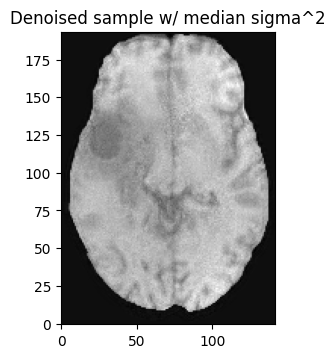

In [28]:
mp_pca = MPPCADenoiser(sigma_estimator="median")

denoised_snapshots_median = mp_pca.fit_transform(snapshots)
print(f"Denoised snapshot shape: {denoised_snapshots_median.shape}")
plot_slices([denoised_snapshots_median[0]], titles=["Denoised sample w/ median sigma^2"])

Denoising 100 snapshots of size 194×142 (sigma_estimator = 'bulk_mean' → sigma_ = 200.066, window_size = 16).
Denoised snapshot shape: (100, 194, 142)


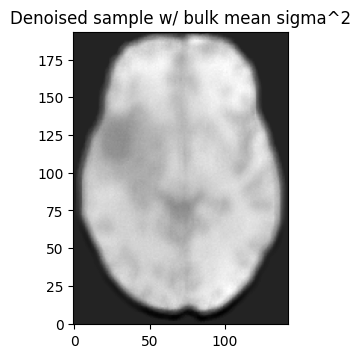

In [29]:
mp_pca = MPPCADenoiser(sigma_estimator="bulk_mean")

denoised_snapshots_bulk_mean = mp_pca.fit_transform(snapshots)
print(f"Denoised snapshot shape: {denoised_snapshots_bulk_mean.shape}")
plot_slices([denoised_snapshots_bulk_mean[0]], titles=["Denoised sample w/ bulk mean sigma^2"])

Denoising 100 snapshots of size 194×142 (sigma_estimator = 'min_eigen' → sigma_ = 26.8983, window_size = 16).
Denoised snapshot shape: (100, 194, 142)


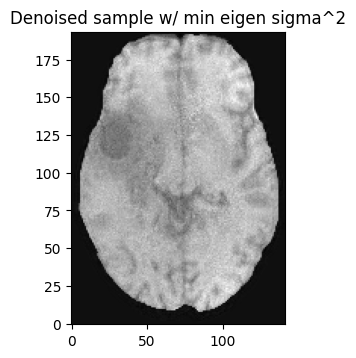

In [30]:
mp_pca = MPPCADenoiser(sigma_estimator="min_eigen")

denoised_snapshots_min_eigen = mp_pca.fit_transform(snapshots)
print(f"Denoised snapshot shape: {denoised_snapshots_min_eigen.shape}")
plot_slices([denoised_snapshots_min_eigen[0]], titles=["Denoised sample w/ min eigen sigma^2"])

Denoising 100 snapshots of size 194×142 (sigma_estimator = 'mp_fit' → sigma_ = 26.4722, window_size = 16).
Denoised snapshot shape: (100, 194, 142)


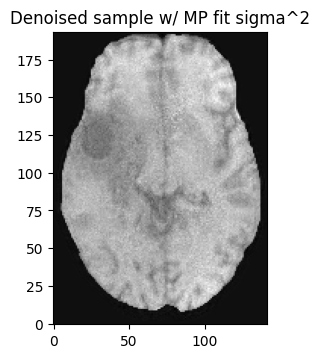

In [31]:
mp_pca = MPPCADenoiser(sigma_estimator="mp_fit")

denoised_snapshots_mp_fit = mp_pca.fit_transform(snapshots)
print(f"Denoised snapshot shape: {denoised_snapshots_mp_fit.shape}")
plot_slices([denoised_snapshots_mp_fit[0]], titles=["Denoised sample w/ MP fit sigma^2"])

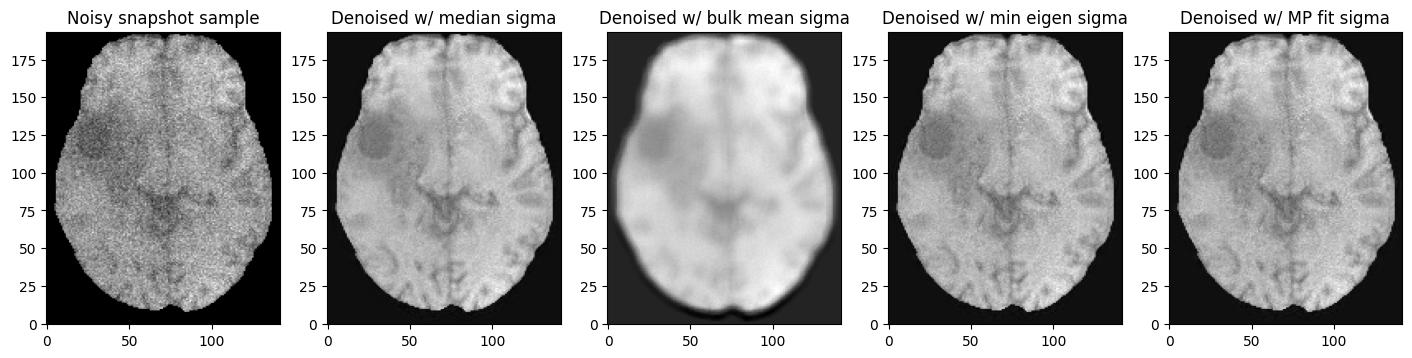

In [35]:
plot_slices(
    [
        snapshots[0],
        denoised_snapshots_median[0],
        denoised_snapshots_bulk_mean[0],
        denoised_snapshots_min_eigen[0],
        denoised_snapshots_mp_fit[0],
    ],
    titles=[
        "Noisy snapshot sample",
        "Denoised w/ median sigma",
        "Denoised w/ bulk mean sigma",
        "Denoised w/ min eigen sigma",
        "Denoised w/ MP fit sigma",
    ],
)